In [ ]:
import sys
print(sys.version)
print(sys.executable)

3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
/Users/jungeli/Documents/Time-Series-Analysis/.venv/bin/python


<!-- %pip install -r requirements.txt -->

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
register_matplotlib_converters()

Matplotlib is building the font cache; this may take a moment.


# Ice Cream Production Data

In [4]:
#read data
df_ice_cream = pd.read_csv('ice_cream.csv')

In [5]:
df_ice_cream.shape

(577, 2)

In [6]:
df_ice_cream.head()

,DATE,IPN31152N
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [10]:
df_ice_cream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DATE       577 non-null    object 
 1   IPN31152N  577 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.1+ KB


In [11]:
#rename columns to something more understandable
df_ice_cream.rename(columns={'DATE':'date', 'IPN31152N':'production'}, inplace=True)

In [12]:
#convert date column to datetime type
df_ice_cream['date'] = pd.to_datetime(df_ice_cream.date)

In [13]:
#set date as index
df_ice_cream.set_index('date', inplace=True)

In [14]:
#just get data from 2010 onwards
start_date = pd.to_datetime('2010-01-01')
df_ice_cream = df_ice_cream[start_date:]

In [15]:
start_date

Timestamp('2010-01-01 00:00:00')

In [16]:
#show result
df_ice_cream.head()

,production
date,
2010-01-01,91.2895
2010-02-01,110.4994
2010-03-01,127.0971
2010-04-01,132.6468
2010-05-01,134.5576


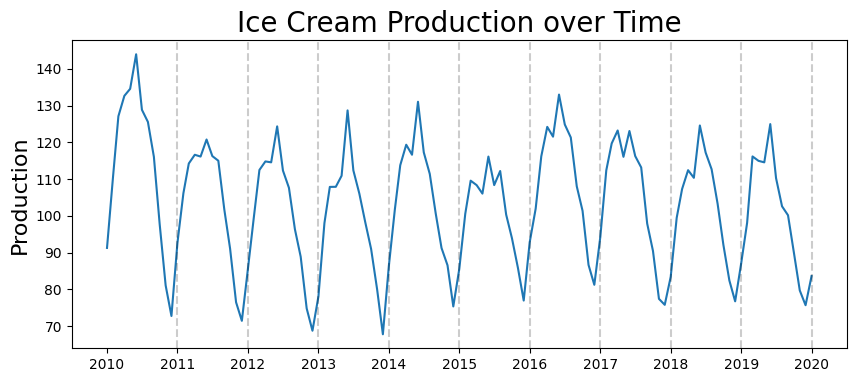

In [17]:
plt.figure(figsize=(10,4))
plt.plot(df_ice_cream.production)
plt.title('Ice Cream Production over Time', fontsize=20)
plt.ylabel('Production', fontsize=16)
for year in range(2011,2021):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

# ACF

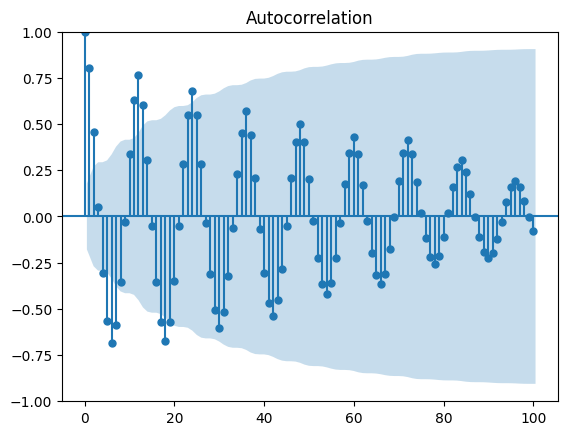

In [18]:
acf_plot = plot_acf(df_ice_cream.production, lags=100)

## Based on decaying ACF, we are likely dealing with an Auto Regressive process

# PACF

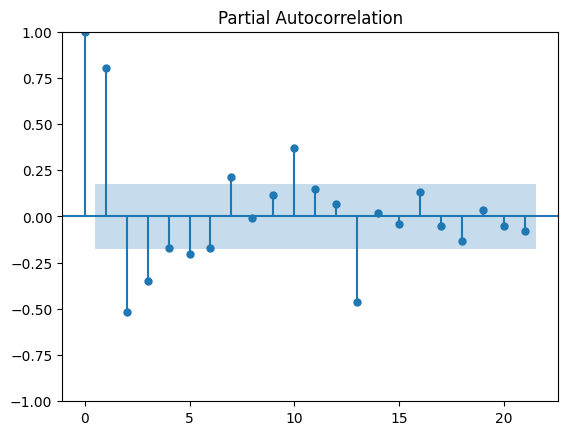

In [19]:
pacf_plot = plot_pacf(df_ice_cream.production)

## Based on PACF, we should start with an Auto Regressive model with lags 1, 2, 3, 10, 13

# On stock data

In [39]:
import yfinance as yf

In [96]:
#define the ticker symbol
tickerSymbol = 'TSLA'#'NVDA' #'SPY'

In [97]:
#get data on this ticker
tickerData = yf.Ticker(tickerSymbol)

In [98]:
type(tickerData)

yfinance.ticker.Ticker

In [99]:
#get the historical prices for this ticker
tickerDf = tickerData.history(period='1d', start='2015-1-1', end='2025-1-1')

In [100]:
tickerDf.head(), tickerDf.tail()

(                                Open       High        Low      Close  \
 Date                                                                    
 2015-01-02 00:00:00-05:00  14.858000  14.883333  14.217333  14.620667   
 2015-01-05 00:00:00-05:00  14.303333  14.433333  13.810667  14.006000   
 2015-01-06 00:00:00-05:00  14.004000  14.280000  13.614000  14.085333   
 2015-01-07 00:00:00-05:00  14.223333  14.318667  13.985333  14.063333   
 2015-01-08 00:00:00-05:00  14.187333  14.253333  14.000667  14.041333   
 
                              Volume  Dividends  Stock Splits  
 Date                                                          
 2015-01-02 00:00:00-05:00  71466000        0.0           0.0  
 2015-01-05 00:00:00-05:00  80527500        0.0           0.0  
 2015-01-06 00:00:00-05:00  93928500        0.0           0.0  
 2015-01-07 00:00:00-05:00  44526000        0.0           0.0  
 2015-01-08 00:00:00-05:00  51637500        0.0           0.0  ,
                               

In [101]:
tickerDf = tickerDf[['Close']]

In [102]:
#see your data
tickerDf.head(), tickerDf.tail()

(                               Close
 Date                                
 2015-01-02 00:00:00-05:00  14.620667
 2015-01-05 00:00:00-05:00  14.006000
 2015-01-06 00:00:00-05:00  14.085333
 2015-01-07 00:00:00-05:00  14.063333
 2015-01-08 00:00:00-05:00  14.041333,
                                 Close
 Date                                 
 2024-12-24 00:00:00-05:00  462.279999
 2024-12-26 00:00:00-05:00  454.130005
 2024-12-27 00:00:00-05:00  431.660004
 2024-12-30 00:00:00-05:00  417.410004
 2024-12-31 00:00:00-05:00  403.839996)

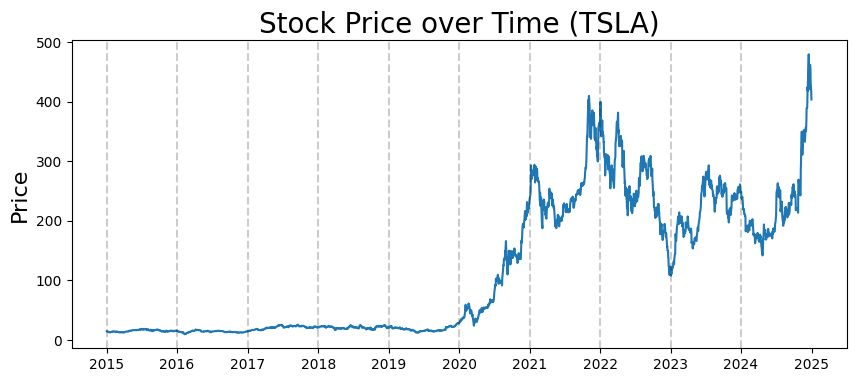

In [103]:
plt.figure(figsize=(10,4))
plt.plot(tickerDf.Close)
plt.title('Stock Price over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(2015,2025):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

## Stationarity: take first difference of this series

In [104]:
#take first difference
first_diffs = tickerDf.Close.values[1:] - tickerDf.Close.values[:-1]
first_diffs = np.concatenate([first_diffs, [0]])

In [105]:
type(first_diffs), first_diffs

(numpy.ndarray,
 array([ -0.61466789,   0.07933331,  -0.02200031, ..., -14.25      ,
        -13.57000732,   0.        ], shape=(2516,)))

In [106]:
#set first difference as variable in dataframe
tickerDf['FirstDifference'] = first_diffs

In [107]:
tickerDf.head(), tickerDf.tail()

(                               Close  FirstDifference
 Date                                                 
 2015-01-02 00:00:00-05:00  14.620667        -0.614668
 2015-01-05 00:00:00-05:00  14.006000         0.079333
 2015-01-06 00:00:00-05:00  14.085333        -0.022000
 2015-01-07 00:00:00-05:00  14.063333        -0.021999
 2015-01-08 00:00:00-05:00  14.041333        -0.264000,
                                 Close  FirstDifference
 Date                                                  
 2024-12-24 00:00:00-05:00  462.279999        -8.149994
 2024-12-26 00:00:00-05:00  454.130005       -22.470001
 2024-12-27 00:00:00-05:00  431.660004       -14.250000
 2024-12-30 00:00:00-05:00  417.410004       -13.570007
 2024-12-31 00:00:00-05:00  403.839996         0.000000)

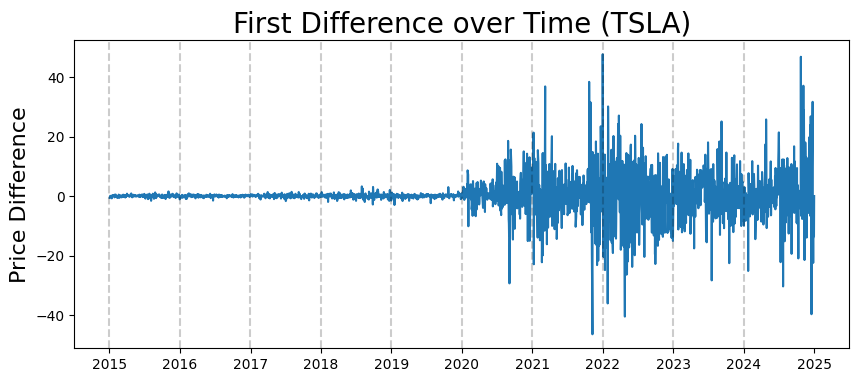

In [108]:
plt.figure(figsize=(10,4))
plt.plot(tickerDf.FirstDifference)
plt.title('First Difference over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price Difference', fontsize=16)
for year in range(2015,2025):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

# ACF

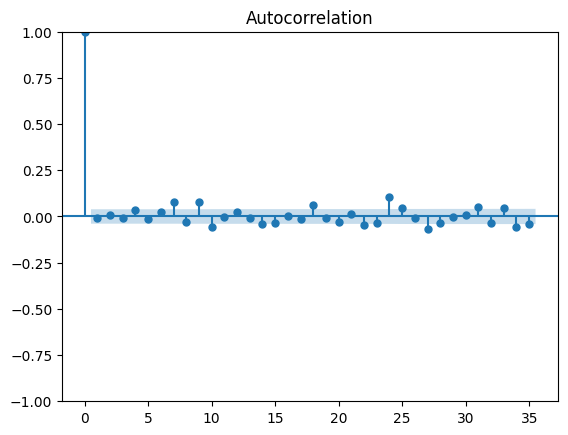

In [109]:
acf_plot = plot_acf(tickerDf.FirstDifference)

## ACF isn't that informative

# PACF

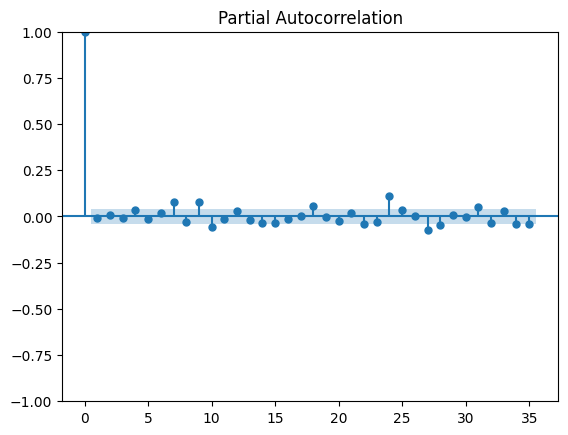

In [110]:
pacf_plot = plot_pacf(tickerDf.FirstDifference)

## PACF also doesn't tell us much